# 02 — Preprocessing: k-fold split, patch generation, augmentation

Building directly on notebook 01's findings:

- Only **19 genuine scenes** survived data cleaning — too few for one fixed train/val/test split (it
  would leave 1-2 scenes for test), so we use **scene-level k-fold cross-validation** instead.
- Waldo boxes are **tiny** (median ~0.14% of the scene) and **class imbalance is extreme** (~1:2345
  under an exhaustive sliding window) — so stage 1's classifier needs to train on *patches*, not full
  scenes, with negatives deliberately undersampled relative to the true imbalance (see
  `src/data/patch_generation.py` for why).

This notebook produces two artifacts notebook 03 will consume:
1. `data/processed/fold_assignment.csv` — which of the 19 scenes belongs to which CV fold.
2. `data/processed/patches/` — the base positive/negative patch corpus (jittered crops, *not yet*
   augmented — flip/rotate/color/scale augmentation is applied live per-epoch in notebook 03, not baked
   in here, so every training epoch sees different augmented versions rather than a fixed static set).

In [1]:
import ast
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import KFold

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.augmentation import augment_patch, build_train_augmentation
from src.data.patch_generation import generate_negative_patches, generate_positive_patches

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PATCHES_DIR = PROCESSED_DIR / "patches"
plt.rcParams["figure.dpi"] = 110

manifest = pd.read_csv(PROCESSED_DIR / "clean_manifest.csv")
manifest["boxes"] = manifest["boxes"].apply(ast.literal_eval)
manifest["scene_id"] = manifest["scene_id"].astype(str)
manifest

,scene_id,split,file_stem,image_path,xml_path,width,height,num_boxes,boxes
0,1,train,1_jpg.rf.371bf634eba70db54e14fe4bd5ca35f0,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(221, 260, 236, 299)]"
1,2,train,2_jpg.rf.41a86f2b02e9553b1904b77f0f808374,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(39, 351, 56, 389)]"
2,3,train,3_jpg.rf.149a8b1d550c63280cee55b2780aa29d,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(433, 217, 452, 246)]"
3,4,valid,4_jpg.rf.bd3fa3245da205a5537fbb81b3b1cc3f,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(464, 139, 474, 161)]"
4,5,train,5_jpg.rf.3110322fed9ae4ed99d02563c14cafaa,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(360, 215, 372, 247)]"
5,6,test,6_jpg.rf.89907196177146ecff8ea8bf5cb87959,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(534, 174, 552, 221)]"
6,7,train,7_jpg.rf.4e2c49e041be4b1361d00d5bfc255d02,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(145, 262, 215, 295)]"
7,8,valid,8_jpg.rf.0ec36d0c0ff8764390b20e36568364ea,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,2,"[(138, 40, 170, 94), (264, 104, 279, 139)]"
8,9,train,9_jpg.rf.0b0e91ce6cef23bb635852b06329c058,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(493, 114, 523, 134)]"
9,10,valid,10_jpg.rf.cc7eec65aa10c04a6049b6efb013d5b7,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,2,"[(168, 48, 199, 105), (286, 101, 296, 129)]"


## Scene-level k-fold split

With 19 scenes we use 5 folds (~4 scenes held out per fold). The split happens on **scene ids**, before
any patch exists — every patch generated from a given scene inherits that scene's fold, so a scene's
crops can never end up on both sides of a train/val boundary. That's the patch-level-leakage guard
notebook 01 flagged as the easy mistake to make.

In [2]:
N_FOLDS = 5
kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

scene_ids = manifest["scene_id"].to_numpy()
fold_rows = []
for fold_idx, (_, val_idx) in enumerate(kfold.split(scene_ids)):
    for scene_id in scene_ids[val_idx]:
        fold_rows.append({"scene_id": scene_id, "val_fold": fold_idx})

fold_assignment = pd.DataFrame(fold_rows).sort_values("scene_id", key=lambda s: s.astype(int))
fold_assignment.to_csv(PROCESSED_DIR / "fold_assignment.csv", index=False)

print(fold_assignment["val_fold"].value_counts().sort_index())
fold_assignment

val_fold
0    4
1    4
2    4
3    4
4    3
Name: count, dtype: int64


,scene_id,val_fold
0,1,0
1,2,0
8,3,2
4,4,1
12,5,3
2,6,0
16,7,4
13,8,3
5,9,1
9,10,2


## Generate the base patch corpus

For every scene: a handful of jittered positive crops per Waldo box, plus a larger pool of random
negative crops that don't overlap any box (see the module docstring in `src/data/patch_generation.py`
for the reasoning behind the exact counts and thresholds). We generate this once for *all* 19 scenes —
the k-fold split above only determines which scene's patches count as train vs. val for a given fold, it
doesn't change what gets generated.

In [3]:
def materialize_patches(manifest: pd.DataFrame, out_dir: Path, seed: int = 0) -> pd.DataFrame:
    (out_dir / "positive").mkdir(parents=True, exist_ok=True)
    (out_dir / "negative").mkdir(parents=True, exist_ok=True)

    records = []
    for _, row in manifest.iterrows():
        rng = np.random.default_rng(seed + int(row["scene_id"]))
        image = Image.open(row["image_path"])

        all_patches = generate_positive_patches(image, row["boxes"], row["scene_id"], rng)
        all_patches += generate_negative_patches(image, row["boxes"], row["scene_id"], rng)

        for i, patch in enumerate(all_patches):
            label_name = "positive" if patch.label == 1 else "negative"
            filename = f"{row['scene_id']}_{label_name}_{i:03d}.png"
            path = out_dir / label_name / filename
            Image.fromarray(patch.image).save(path)
            records.append({"scene_id": row["scene_id"], "label": patch.label, "path": str(path)})

    return pd.DataFrame(records)


patch_manifest = materialize_patches(manifest, PATCHES_DIR)
patch_manifest.to_csv(PROCESSED_DIR / "patch_manifest.csv", index=False)
print(f"{len(patch_manifest)} patches written to {PATCHES_DIR}")
patch_manifest["label"].value_counts()

886 patches written to D:\python_envs\wheres-wally\data\processed\patches


label
0    760
1    126
Name: count, dtype: int64

## Look at the patches

Same reason as notebook 01: catch a bug by eye before trusting the numbers. Positive patches should
clearly show Waldo (red-white stripes, hat) roughly centered but with visible jitter in framing;
negatives should show background clutter with no Waldo.

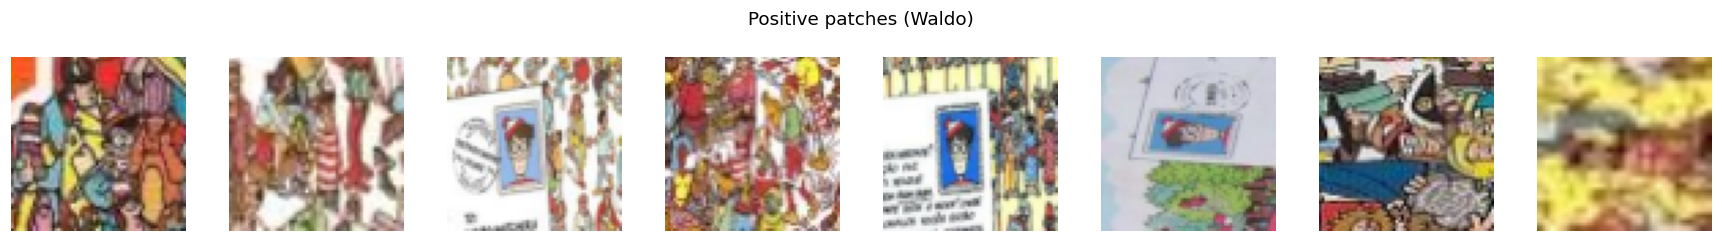

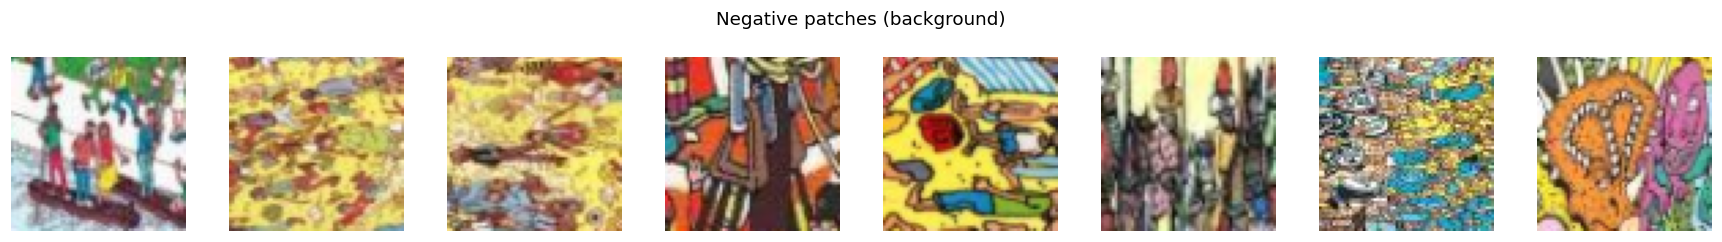

In [4]:
def show_patch_grid(paths: list[str], title: str):
    fig, axes = plt.subplots(1, len(paths), figsize=(2 * len(paths), 2.2))
    for ax, p in zip(axes, paths):
        ax.imshow(Image.open(p))
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


pos_sample = patch_manifest[patch_manifest["label"] == 1].sample(8, random_state=0)["path"].tolist()
neg_sample = patch_manifest[patch_manifest["label"] == 0].sample(8, random_state=0)["path"].tolist()
show_patch_grid(pos_sample, "Positive patches (Waldo)")
show_patch_grid(neg_sample, "Negative patches (background)")

## Augmentation preview

This is *not* applied to the saved patches above — `build_train_augmentation()` (from
`src/data/augmentation.py`) gets called live inside the training loop in notebook 03, once per epoch per
sample, so the model never sees the exact same pixels twice. Here we just preview what it does to a
single positive patch, repeated, to sanity-check the transform strengths are reasonable (recognizable
Waldo, not destroyed).

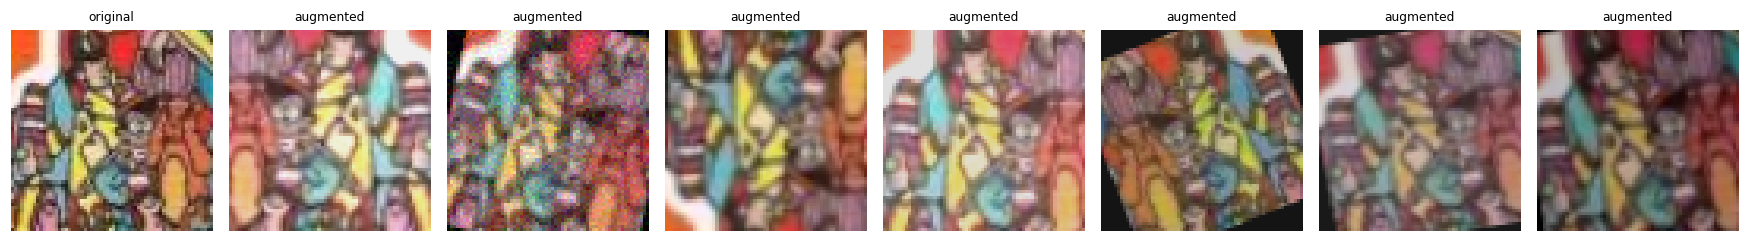

In [5]:
augmenter = build_train_augmentation()
base_patch = np.array(Image.open(pos_sample[0]))

fig, axes = plt.subplots(1, 8, figsize=(16, 2.2))
axes[0].imshow(base_patch)
axes[0].set_title("original", fontsize=8)
for ax in axes[1:]:
    ax.imshow(augment_patch(base_patch, augmenter))
    ax.set_title("augmented", fontsize=8)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Verify patch-level leakage is impossible by construction

Every patch's filename is prefixed with its source `scene_id`, and every scene has exactly one fold
assignment. So for any fold, a patch is either fully in train or fully in val — there's no way for two
patches of the *same scene* to land on opposite sides. We check this directly rather than trusting the
construction.

In [6]:
merged = patch_manifest.merge(fold_assignment, on="scene_id", how="left")

for fold in range(N_FOLDS):
    val_scenes = set(merged.loc[merged["val_fold"] == fold, "scene_id"])
    train_scenes = set(merged.loc[merged["val_fold"] != fold, "scene_id"])
    overlap = val_scenes & train_scenes
    n_train_patches = (merged["val_fold"] != fold).sum()
    n_val_patches = (merged["val_fold"] == fold).sum()
    print(
        f"fold {fold}: {len(train_scenes)} train scenes ({n_train_patches} patches), "
        f"{len(val_scenes)} val scenes ({n_val_patches} patches), scene overlap: {len(overlap)}"
    )
    assert not overlap, f"Fold {fold} leaks scenes between train and val!"

fold 0: 15 train scenes (702 patches), 4 val scenes (184 patches), scene overlap: 0
fold 1: 15 train scenes (696 patches), 4 val scenes (190 patches), scene overlap: 0
fold 2: 15 train scenes (696 patches), 4 val scenes (190 patches), scene overlap: 0
fold 3: 15 train scenes (696 patches), 4 val scenes (190 patches), scene overlap: 0
fold 4: 16 train scenes (754 patches), 3 val scenes (132 patches), scene overlap: 0


## Takeaways → what this motivates for notebook 03

- We now have a materialized patch corpus (`data/processed/patches/`, indexed by
  `data/processed/patch_manifest.csv`) and a scene-level 5-fold assignment
  (`data/processed/fold_assignment.csv`), with leakage-freedom checked directly rather than assumed.
- Positive patches carry generation-time jitter (crop framing); augmentation (flip/rotate/color/scale)
  is deliberately *not* baked in, so notebook 03's `Dataset` needs to apply `build_train_augmentation()`
  live, on training patches only (never on validation patches, which must stay a fixed, comparable
  target across epochs).
- Negatives here are undersampled/easy (random crops). Notebook 03's training loop should, after an
  initial pass, mine **hard negatives** — false positives from the current model — and add them to the
  training pool, since easy random negatives alone will plateau quickly against real background clutter.
- With 5 folds over 19 scenes, notebook 03 should train and evaluate across all 5 folds (not just one)
  and report metrics aggregated across folds, given how much a single 4-scene validation set can vary.